![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cities dataset
cities = pd.read_csv('us-cities-top-1k-multi-year.csv')

# Job automation dataset
jobs = pd.read_csv('job-automation-probability.csv')

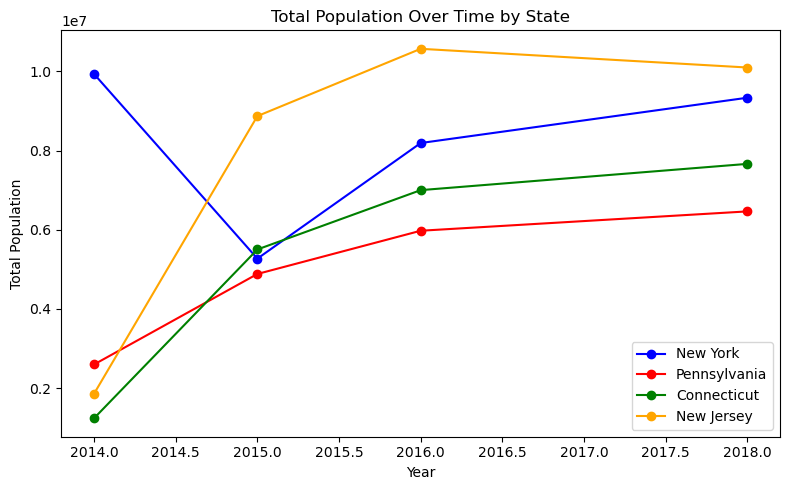

In [3]:
# Question 1

states = ['New York', 'Pennsylvania', 'Connecticut', 'New Jersey']
colors = {
    'New York': 'blue',
    'Pennsylvania': 'red',
    'Connecticut': 'green',
    'New Jersey': 'orange'
}

# Sum total population per state per year across all cities
state_pop = cities[cities['State'].isin(states)].groupby(
    ['year', 'State']
)['Population'].sum().reset_index()

plt.figure(figsize=(8,5))

for state in states:
    data = state_pop[state_pop['State'] == state]
    plt.plot(data['year'], data['Population'],
             marker='o', color=colors[state], label=state)

plt.title('Total Population Over Time by State')
plt.xlabel('Year')
plt.ylabel('Total Population')
plt.legend()
plt.tight_layout()
plt.show()

['Binghamton', 'Freeport', 'Niagara Falls', 'Schenectady', 'Yonkers']


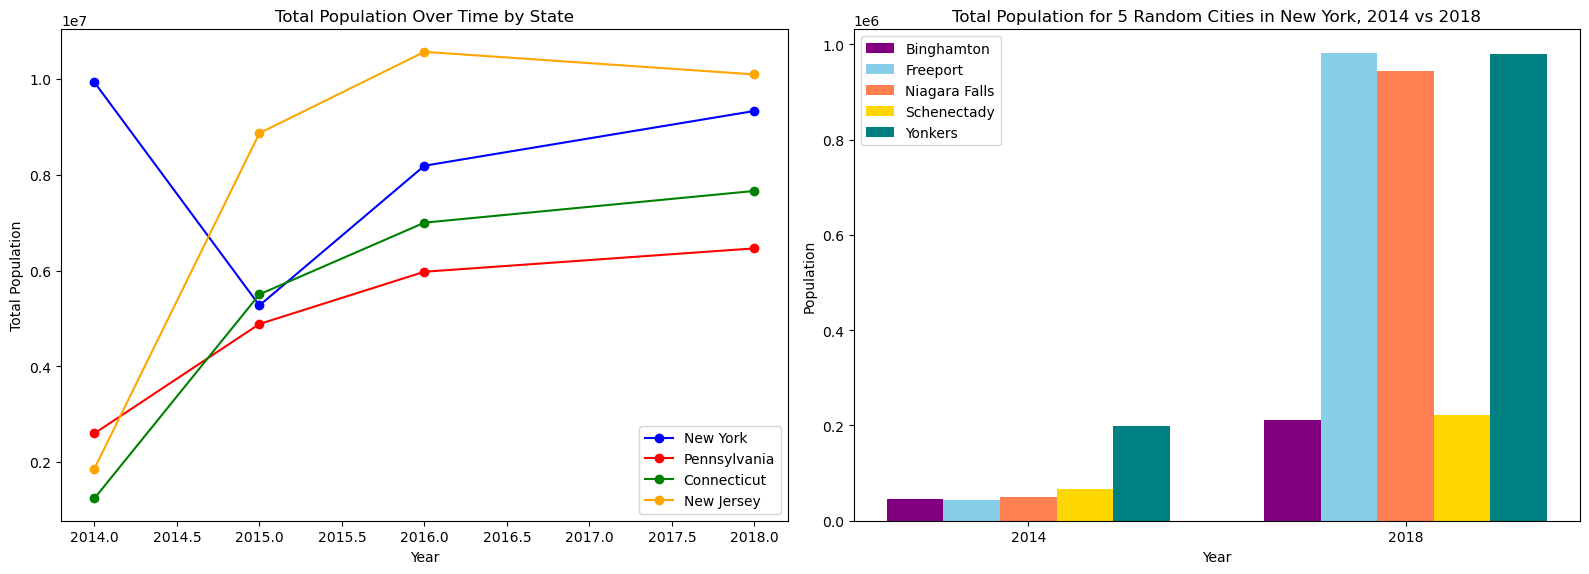

In [4]:
# Question 2

# 5 random NY cities from 2014
random_ny = cities[
    (cities['State'] == 'New York') & (cities['year'] == 2014)
]['City'].sample(n=5, random_state=1).tolist()

print(random_ny)

# Keep only those cities
ny_cities_df = cities[cities['City'].isin(random_ny)]

# Group by year and city
ny_city_plot = ny_cities_df.groupby(
    ['year', 'City']
)['Population'].sum().reset_index()

# Keep only 2014 and 2018
ny_city_plot = ny_city_plot[
    (ny_city_plot['year'] == 2014) | (ny_city_plot['year'] == 2018)
]

# Combine Question 1 and Question 2 in one figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First graph: line graph
for state in states:
    data = state_pop[state_pop['State'] == state]
    ax1.plot(data['year'], data['Population'],
             marker='o', color=colors[state], label=state)

ax1.set_title('Total Population Over Time by State')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Population')
ax1.legend()

# Second graph: bar graph
bar_width = 0.15
x = np.array([0, 1])   # positions for 2014 and 2018
years = [2014, 2018]
city_colors = ['purple', 'skyblue', 'coral', 'gold', 'teal']

for i, city in enumerate(random_ny):
    city_data = ny_city_plot[ny_city_plot['City'] == city].sort_values('year')
    ax2.bar(x + i * bar_width, city_data['Population'],
            width=bar_width, color=city_colors[i], label=city)

ax2.set_title('Total Population for 5 Random Cities in New York, 2014 vs 2018')
ax2.set_xlabel('Year')
ax2.set_ylabel('Population')
ax2.set_xticks(x + 2 * bar_width)
ax2.set_xticklabels(years)
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:
print(jobs.columns)

Index(['_ - rank', '_ - code', 'prob', 'Average annual wage', 'education',
       'occupation', 'short occupation', 'len', 'probability', 'numbEmployed',
       'median_ann_wage', 'employed_may2016', 'average_ann_wage'],
      dtype='object')


In [19]:
for col in jobs.columns:
    print(repr(col))

'____rank'
'____code'
'prob'
'average_annual_wage'
'education'
'occupation'
'short_occupation'
'len'
'probability'
'numbemployed'
'median_ann_wage'
'employed_may2016'
'average_ann_wage'


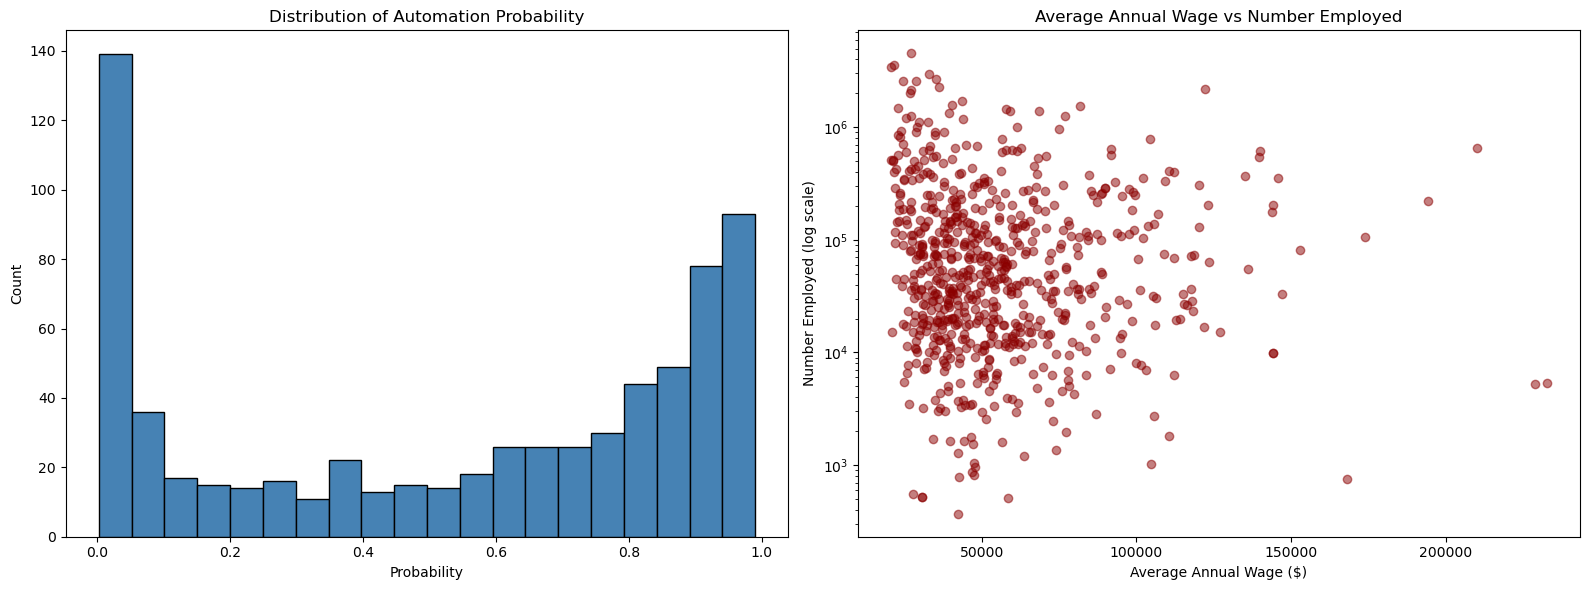

In [21]:
# Question 3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# histogram
ax1.hist(df2['probability'], bins=20, color='steelblue', edgecolor='black')
ax1.set_title('Distribution of Automation Probability')
ax1.set_xlabel('Probability')
ax1.set_ylabel('Count')

# scatter
ax2.scatter(df2['average_ann_wage'], df2['numbemployed'], color='darkred', alpha=0.5)
ax2.set_yscale('log')
ax2.set_title('Average Annual Wage vs Number Employed')
ax2.set_xlabel('Average Annual Wage ($)')
ax2.set_ylabel('Number Employed (log scale)')

plt.tight_layout()
plt.savefig('question3_figure.png')
plt.show()